In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [2]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2)

In [3]:
X

array([[ 0.70079134,  2.18652939],
       [-5.12092995, -2.69704051],
       [-7.02966548, -3.33157829],
       ...,
       [-5.66329504, -4.25970382],
       [-0.40852951,  2.92536995],
       [ 1.52511443,  5.38148355]])

In [5]:
y

array([1, 2, 2, 2, 2, 2, 0, 0, 1, 0, 0, 1, 2, 0, 0, 0, 0, 1, 2, 1, 2, 0,
       0, 1, 2, 0, 1, 2, 1, 1, 2, 2, 0, 0, 1, 0, 0, 0, 2, 1, 1, 1, 0, 1,
       0, 2, 1, 1, 2, 0, 2, 1, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 0, 2, 2,
       2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 2, 1, 0, 1, 1, 1, 1, 2, 0, 2, 1,
       1, 1, 0, 1, 2, 1, 0, 0, 1, 0, 1, 1, 2, 0, 1, 0, 2, 0, 0, 2, 2, 1,
       2, 2, 1, 2, 0, 0, 2, 2, 0, 1, 0, 2, 0, 0, 1, 0, 1, 2, 0, 1, 2, 2,
       1, 0, 0, 2, 1, 1, 0, 0, 1, 1, 0, 2, 0, 1, 0, 0, 0, 2, 2, 2, 2, 1,
       2, 1, 1, 2, 1, 1, 2, 0, 1, 0, 1, 2, 0, 2, 0, 1, 2, 0, 2, 1, 1, 0,
       1, 0, 1, 1, 1, 2, 1, 2, 2, 1, 1, 1, 2, 1, 0, 0, 0, 0, 2, 2, 2, 2,
       2, 1, 1, 0, 2, 0, 0, 0, 2, 0, 1, 2, 2, 2, 0, 0, 0, 2, 1, 1, 2, 2,
       2, 0, 0, 0, 1, 2, 1, 2, 0, 2, 0, 1, 0, 2, 2, 2, 0, 1, 2, 0, 1, 1,
       1, 0, 1, 0, 2, 2, 1, 0, 2, 1, 0, 0, 1, 0, 0, 1, 0, 2, 0, 2, 2, 0,
       1, 1, 0, 2, 2, 0, 2, 1, 2, 1, 0, 2, 1, 0, 0, 1, 0, 2, 2, 1, 2, 2,
       2, 0, 1, 0, 1, 2, 1, 2, 0, 0, 1, 0, 1, 2, 2,

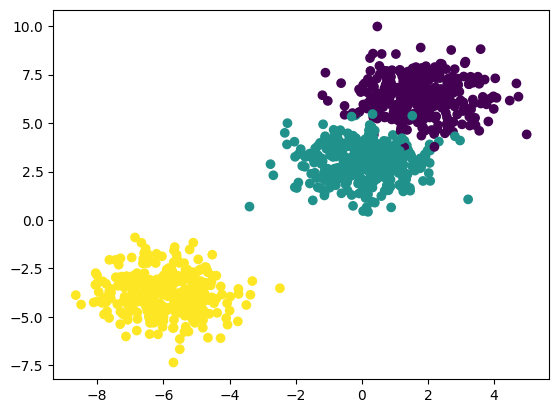

In [6]:
plt.scatter(X[:,0],X[:,1],c=y)

In [7]:
## standardization--feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [8]:
from sklearn.model_selection import train_test_split    

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=42)

In [10]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [11]:
from sklearn.cluster import KMeans

In [12]:
## Elbow method To select K Value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [13]:
wcss

[1340.0000000000005,
 192.95448100704687,
 94.42674963634961,
 81.9050021026973,
 68.63694105721287,
 55.91775397181364,
 50.19105724081665,
 47.031102651789354,
 40.82426522236407,
 36.62990135142004]

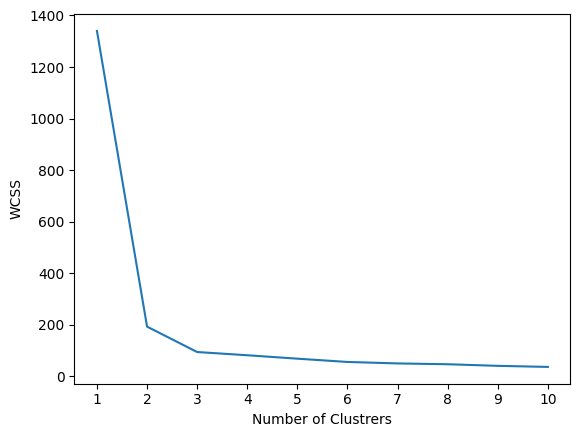

In [14]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

In [15]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [16]:
kmeans.fit_predict(X_train_scaled)

array([1, 0, 0, 1, 0, 0, 0, 0, 0, 2, 1, 2, 1, 2, 0, 0, 2, 0, 2, 2, 1, 2,
       2, 2, 1, 1, 1, 0, 1, 2, 1, 1, 1, 2, 0, 0, 1, 2, 0, 2, 0, 0, 0, 0,
       2, 2, 0, 2, 2, 2, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 2, 2,
       2, 2, 1, 1, 1, 2, 0, 0, 1, 0, 0, 2, 0, 1, 0, 0, 0, 0, 0, 1, 2, 1,
       0, 2, 1, 2, 1, 0, 0, 0, 0, 2, 1, 1, 1, 1, 0, 0, 2, 1, 0, 2, 1, 0,
       2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 2, 0, 2, 0, 0, 1, 1, 0, 2, 2, 1,
       2, 1, 1, 1, 2, 2, 1, 2, 1, 1, 0, 0, 0, 1, 0, 0, 2, 0, 0, 2, 0, 2,
       2, 0, 2, 2, 1, 1, 1, 1, 1, 1, 2, 0, 0, 1, 1, 2, 2, 2, 0, 0, 1, 0,
       1, 1, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0, 2, 2, 1, 2, 0, 0, 2, 2, 1, 2,
       1, 0, 2, 2, 0, 1, 2, 0, 0, 0, 0, 2, 1, 0, 2, 2, 1, 1, 2, 1, 1, 0,
       1, 0, 0, 2, 0, 2, 2, 1, 0, 1, 1, 2, 2, 1, 2, 2, 2, 2, 1, 0, 1, 0,
       1, 1, 2, 0, 2, 2, 0, 0, 1, 0, 2, 2, 1, 0, 0, 0, 1, 2, 2, 2, 2, 0,
       1, 1, 2, 1, 1, 2, 0, 1, 1, 2, 2, 1, 2, 2, 2, 2, 0, 1, 1, 1, 2, 1,
       2, 0, 2, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 0, 2,

In [19]:
y_pred=kmeans.predict(X_test_scaled)

In [20]:
y_pred

array([1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 2, 0, 1, 2, 0, 2, 0, 0, 0,
       2, 1, 1, 1, 2, 2, 1, 1, 2, 2, 1, 2, 2, 1, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 2, 0, 1, 2, 1, 2, 1, 1, 1, 0, 1, 1, 2, 2, 1, 0, 2, 1, 1, 2, 2,
       2, 1, 2, 2, 1, 0, 2, 0, 0, 2, 1, 0, 2, 2, 0, 1, 1, 2, 0, 1, 0, 2,
       0, 2, 2, 0, 1, 1, 0, 2, 0, 0, 0, 1, 0, 0, 2, 2, 2, 2, 2, 1, 2, 2,
       0, 1, 0, 0, 1, 2, 1, 0, 1, 2, 0, 2, 0, 2, 0, 1, 0, 1, 0, 0, 1, 2,
       0, 2, 1, 1, 2, 1, 2, 2, 2, 1, 0, 1, 1, 0, 0, 0, 0, 2, 0, 0, 2, 0,
       2, 2, 1, 1, 2, 1, 2, 0, 2, 1, 1, 0, 0, 1, 0, 1, 2, 2, 1, 0, 0, 2,
       0, 1, 2, 2, 1, 0, 1, 2, 2, 0, 0, 2, 2, 1, 2, 1, 0, 0, 2, 2, 1, 0,
       2, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 2, 0, 0, 2, 0, 2,
       2, 1, 0, 2, 2, 1, 0, 1, 0, 2, 2, 1, 0, 2, 2, 1, 0, 1, 2, 2, 1, 2,
       1, 0, 0, 0, 2, 1, 1, 1, 0, 2, 0, 0, 2, 2, 0, 1, 1, 1, 2, 0, 2, 2,
       1, 0, 1, 0, 0, 2, 0, 2, 1, 1, 0, 2, 1, 0, 0, 2, 2, 1, 2, 0, 1, 0,
       1, 2, 1, 1, 2, 2, 0, 2, 1, 2, 1, 2, 2, 0, 1,

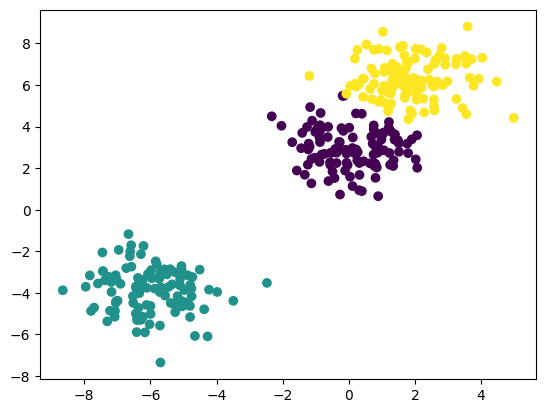

In [21]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [ ]:

## Validating the k value:
## 1. kneelocator
## 2. Silhouette scoring

In [23]:
## kneelocator
!pip install kneed


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
from kneed import KneeLocator

In [25]:
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [26]:
kl.elbow

2

In [27]:
## silhoutte score
from sklearn.metrics import silhouette_score

In [28]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

In [29]:
silhouette_coefficients

[0.757155679879216,
 0.6163058024001971,
 0.4662095432935685,
 0.33601681410431733,
 0.39484597207001104,
 0.3531835250864083,
 0.35103157721060596,
 0.3531543063972393,
 0.32597616527412404]

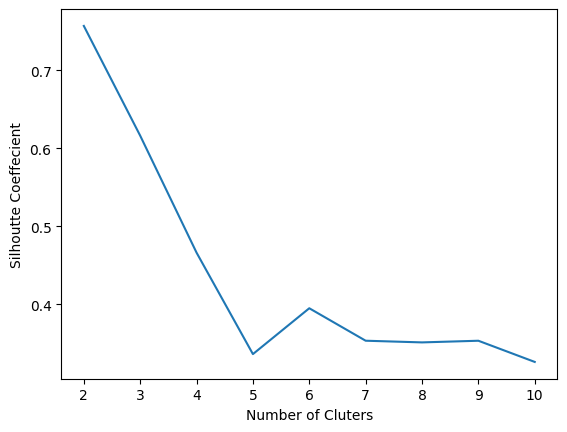

In [30]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()